# Comprehensive 5-Year Financial Analysis of the US Big Five Tech Giants

**Companies:** Apple (AAPL) · Microsoft (MSFT) · Alphabet/Google (GOOGL) · Amazon (AMZN) · Meta (META)
**Fiscal Years:** 2020 – 2024
**Data Source:** WRDS · Compustat North America (`comp.funda`, `comp.company`)
**Module:** ACC102 – Artificial Intelligence-Driven Data Analytics
**Track:** 2 – GitHub Data Analysis Project

---

## Notebook Outline

| # | Section | Output |
|---|---------|--------|
| 1 | Problem Definition & Target User | Markdown |
| 2 | Data Source & Query Design | Markdown |
| 3 | Environment Setup & WRDS Connection | Code |
| 4 | Parameterised SQL with `LEFT JOIN` (f-string) | Code |
| 5 | Data Cleaning & Feature Engineering | Code |
| 6 | **Chart 1** – Annual Revenue Trend | Chart + Insight |
| 7 | **Chart 2** – Net Income Trend | Chart + Insight |
| 8 | **Chart 3** – Gross Margin Comparison | Chart + Insight |
| 9 | **Chart 4** – Revenue Growth Rate (YoY) | Chart + Insight |
| 10 | **Chart 5** – Net Profit Margin | Chart + Insight |
| 11 | **Chart 6** – Scale Comparison (FY 2024) | Chart + Insight |
| 12 | **Chart 7** – Correlation Heatmap of Key Metrics | Chart + Insight |
| 13 | Cross-Company Synthesis | Markdown |
| 14 | Reusable Functions (for later Agent / Plugin integration) | Code |
| 15 | Limitations & Next Steps | Markdown |


## 1. Problem Definition & Target User

### Analytical Problem

The five largest US technology companies — Apple, Microsoft, Alphabet, Amazon, and Meta — collectively account for a large share of the S&P 500's market capitalisation. Despite being grouped together, their **business models are fundamentally different**:

- **Apple** — consumer hardware with a growing services layer
- **Microsoft** — enterprise software and cloud (Azure)
- **Alphabet** — advertising-funded search, plus YouTube and Google Cloud
- **Amazon** — e-commerce retail plus AWS (cloud)
- **Meta** — advertising-funded social platforms

These structural differences show up clearly in their financial statements. This notebook asks a single, concrete question:

> **Over the five fiscal years 2020–2024, how did the revenue, profitability, and scale of the US Big Five diverge, and which financial metrics move together across the group?**

### Target User

The intended user is a **junior equity analyst** covering the US large-cap technology sector, or a **finance student** preparing an industry note. The user needs:

1. A quick, visual comparison across peers.
2. Derived ratios (margins, growth) rather than only raw dollar figures.
3. A reproducible pipeline that can be re-run next quarter with updated data.

### Why this matters

Raw revenue in dollars hides structure. A company earning \$100 bn in hardware sales at 40% gross margin is a very different business from one earning \$100 bn in software at 80% gross margin. Building a *comparable* picture — not just a ranked list — is the core task.


## 2. Data Source & Query Design

### Source

**WRDS (Wharton Research Data Services) → Compustat North America → Annual Fundamentals (`comp.funda`).**

- `comp.funda` contains one row per firm-fiscal year, with standardised income-statement and balance-sheet items.
- `comp.company` maps `gvkey` (Compustat's permanent firm identifier) to the current ticker (`tic`) and company name (`conm`).
- The `LEFT JOIN` pattern follows the Week 6 lecture example (joining `crsp.msf` with `crsp.msfhdr`), just applied to a different pair of tables.

### Key variables we request

| Compustat field | Meaning | Used for |
|---|---|---|
| `revt` | Revenue – total | Charts 1, 4, 6 |
| `cogs` | Cost of goods sold | Gross profit / margin |
| `ni` | Net income (loss) | Charts 2, 5 |
| `gp` | Gross profit (when populated) | Cross-check |
| `at` | Total assets | Chart 6 (scale) |
| `oiadp` | Operating income after depreciation | Optional deeper ratios |
| `datadate`, `fyear` | Fiscal-year identifiers | Time axis |
| `tic`, `conm` | Ticker, company name | Labels |

### Compustat filters (important)

To avoid duplicate rows and restatements, we apply the **standard Compustat screen**:

```
indfmt = 'INDL'     -- industrial format (not financial services)
datafmt = 'STD'     -- standardised, not restated
popsrc = 'D'        -- domestic
consol = 'C'        -- consolidated
```

Without these, a single firm-year can appear multiple times. This is a common source of errors in student work.

### Data access date

The code below records the access date automatically so the notebook is self-documenting.


## 3. Environment Setup & WRDS Connection

In [20]:
# Standard scientific-Python stack
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot styling — consistent across all 7 charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

# Record the run time — the reflection report cites this as the data-access date
ACCESS_DATE = datetime.now().strftime('%Y-%m-%d')
print(f'Notebook executed on: {ACCESS_DATE}')
print(f'pandas {pd.__version__} · numpy {np.__version__}')

Notebook executed on: 2026-04-23
pandas 2.2.3 · numpy 2.3.5


Connect to WRDS. The first time this runs in a new environment WRDS will prompt for username and password, and offer to cache credentials in `~/.pgpass`. The credentials **are never hard-coded** in the notebook.

In [21]:
# Connect. WRDS will prompt interactively if credentials are not cached.
db = wrds.Connection()
print('Connection established.')

Enter your WRDS username [yangmaini]: lixinyuaria
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Connection established.


## 4. Parameterised SQL with `LEFT JOIN` (f-string)

Following the Week 6 lecture, we do **not** hard-code the ticker list or the date inside the SQL string. Anything that might change on the next run — tickers, start date, selected columns — is lifted out into Python variables.

### Why parameterise?

- **Reproducibility** — to extend the study to 2025, change one line.
- **Reusability** — the same code becomes a function in section 14.
- **Reviewability** — the marker can see at a glance what is being asked of the database.

### Small SQL-injection note

In production code, using f-strings to build SQL is **not** best practice because of injection risk. Here the inputs (tickers, dates) come from a controlled Python list, not user input, so the risk is nil. For a real product we would use parameterised queries (`%s` placeholders). This is flagged honestly in the reflection.

In [22]:
# ---------- Parameters ----------
TICKERS    = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
START_DATE = '2020-01-01'      # covers fiscal years 2020 onwards
END_DATE   = '2024-12-31'      # up to and including FY 2024

# ---------- SELECT list ----------
COLUMNS = '''
    b.conm,
    a.gvkey,
    a.datadate,
    a.fyear,
    a.revt,
    a.cogs,
    a.gp,
    a.ni,
    a.oiadp,
    a.at,
    a.tic
'''

# ---------- Build the IN-list safely ----------
tickers_sql = "', '".join(TICKERS)   # -> AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META

# ---------- f-string query ----------
sql_query = f"""
SELECT {COLUMNS}
FROM   comp.funda AS a
LEFT JOIN comp.company AS b
       ON a.gvkey = b.gvkey
WHERE  a.tic IN ('{tickers_sql}')
  AND  a.datadate BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND  a.indfmt  = 'INDL'
  AND  a.datafmt = 'STD'
  AND  a.popsrc  = 'D'
  AND  a.consol  = 'C'
ORDER BY a.tic, a.fyear
"""

print(sql_query)


SELECT 
    b.conm,
    a.gvkey,
    a.datadate,
    a.fyear,
    a.revt,
    a.cogs,
    a.gp,
    a.ni,
    a.oiadp,
    a.at,
    a.tic

FROM   comp.funda AS a
LEFT JOIN comp.company AS b
       ON a.gvkey = b.gvkey
WHERE  a.tic IN ('AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META')
  AND  a.datadate BETWEEN '2020-01-01' AND '2024-12-31'
  AND  a.indfmt  = 'INDL'
  AND  a.datafmt = 'STD'
  AND  a.popsrc  = 'D'
  AND  a.consol  = 'C'
ORDER BY a.tic, a.fyear



Execute the query and bring the result into a pandas DataFrame.

In [23]:
raw = db.raw_sql(sql_query)
print(f'Rows returned : {len(raw)}')
print(f'Firms covered : {raw["tic"].nunique()}')
print(f'Years covered : {sorted(raw["fyear"].dropna().unique().astype(int).tolist())}')
raw.head(10)


Rows returned : 25
Firms covered : 5
Years covered : [2020, 2021, 2022, 2023, 2024]


,conm,gvkey,datadate,fyear,revt,cogs,gp,ni,oiadp,at,tic
0,APPLE INC,001690,2020-09-30,2020,274515.0,159859.0,114656.0,57411.0,66288.0,323888.0,AAPL
1,APPLE INC,001690,2021-09-30,2021,365817.0,203481.0,162336.0,94680.0,108949.0,351002.0,AAPL
2,APPLE INC,001690,2022-09-30,2022,394328.0,214846.0,179482.0,99803.0,119437.0,352755.0,AAPL
3,APPLE INC,001690,2023-09-30,2023,383285.0,205637.0,177648.0,96995.0,114301.0,352583.0,AAPL
4,APPLE INC,001690,2024-09-30,2024,391035.0,202152.0,188883.0,93736.0,123216.0,364980.0,AAPL
5,AMAZON.COM INC,064768,2020-12-31,2020,386064.0,217068.0,168996.0,21331.0,22315.0,321195.0,AMZN
6,AMAZON.COM INC,064768,2021-12-31,2021,469822.0,249435.0,220387.0,33364.0,24429.0,420549.0,AMZN
7,AMAZON.COM INC,064768,2022-12-31,2022,513983.0,263907.0,250076.0,-2722.0,12907.0,462675.0,AMZN
8,AMAZON.COM INC,064768,2023-12-31,2023,574785.0,274514.0,300271.0,30425.0,36913.0,527854.0,AMZN
9,AMAZON.COM INC,064768,2024-12-31,2024,637959.0,294221.0,343738.0,59248.0,69438.0,624894.0,AMZN


In [24]:
# Quick integrity check — every firm should have ~5 rows (one per fiscal year)
raw.groupby('tic').size().rename('n_rows')

tic
AAPL     5
AMZN     5
GOOGL    5
META     5
MSFT     5
Name: n_rows, dtype: int64

## 5. Data Cleaning & Feature Engineering

Even data pulled from a curated vendor needs a cleaning step. Here we:

1. Drop rows where `fyear` or `revt` is missing (a firm-year with no revenue reported is not usable).
2. Convert `fyear` to integer (Compustat returns it as a float because of `NaN` semantics).
3. Compute **gross profit** directly as `revt − cogs`. We do not rely on `gp`, because Compustat's `gp` field is not populated consistently across firms and years.
4. Convert dollar figures to **USD billions** for readability.
5. Compute the **derived ratios** that the charts need:
   - Gross margin = gross profit ÷ revenue
   - Net margin = net income ÷ revenue
   - Revenue growth (YoY) = revenue<sub>t</sub> ÷ revenue<sub>t−1</sub> − 1
6. Rename columns into human-readable labels for the final table and AI prompts.

In [25]:
df = raw.copy()

# 1. Drop firm-years with missing essentials
df = df.dropna(subset=['fyear', 'revt']).copy()

# 2. Integer fiscal year
df['fyear'] = df['fyear'].astype(int)

# 3. Recompute gross profit (avoid relying on inconsistent gp field)
df['gross_profit'] = df['revt'] - df['cogs']

# 4. Rescale to USD billions
for col, new in [('revt', 'revenue_bn'),
                 ('ni', 'net_income_bn'),
                 ('gross_profit', 'gross_profit_bn'),
                 ('at', 'total_assets_bn'),
                 ('oiadp', 'op_income_bn')]:
    df[new] = df[col] / 1_000

# 5. Derived ratios
df['gross_margin'] = df['gross_profit'] / df['revt']
df['net_margin']   = df['ni']           / df['revt']

# Revenue growth requires a sort within each firm
df = df.sort_values(['tic', 'fyear']).reset_index(drop=True)
df['revenue_growth'] = df.groupby('tic')['revt'].pct_change()

# 6. Friendly labels for presentation
display_df = df.rename(columns={
    'tic':              'Ticker',
    'conm':             'Company',
    'fyear':            'Fiscal Year',
    'revenue_bn':       'Revenue (USD bn)',
    'net_income_bn':    'Net Income (USD bn)',
    'gross_profit_bn':  'Gross Profit (USD bn)',
    'total_assets_bn':  'Total Assets (USD bn)',
    'gross_margin':     'Gross Margin',
    'net_margin':       'Net Margin',
    'revenue_growth':   'Revenue YoY',
})[['Ticker','Company','Fiscal Year','Revenue (USD bn)',
    'Net Income (USD bn)','Gross Profit (USD bn)','Total Assets (USD bn)',
    'Gross Margin','Net Margin','Revenue YoY']]

display_df.round(3)


,Ticker,Company,Fiscal Year,Revenue (USD bn),Net Income (USD bn),Gross Profit (USD bn),Total Assets (USD bn),Gross Margin,Net Margin,Revenue YoY
0,AAPL,APPLE INC,2020,274.515,57.411,114.656,323.888,0.418,0.209,<NA>
1,AAPL,APPLE INC,2021,365.817,94.68,162.336,351.002,0.444,0.259,0.333
2,AAPL,APPLE INC,2022,394.328,99.803,179.482,352.755,0.455,0.253,0.078
3,AAPL,APPLE INC,2023,383.285,96.995,177.648,352.583,0.463,0.253,-0.028
4,AAPL,APPLE INC,2024,391.035,93.736,188.883,364.98,0.483,0.24,0.02
5,AMZN,AMAZON.COM INC,2020,386.064,21.331,168.996,321.195,0.438,0.055,<NA>
6,AMZN,AMAZON.COM INC,2021,469.822,33.364,220.387,420.549,0.469,0.071,0.217
7,AMZN,AMAZON.COM INC,2022,513.983,-2.722,250.076,462.675,0.487,-0.005,0.094
8,AMZN,AMAZON.COM INC,2023,574.785,30.425,300.271,527.854,0.522,0.053,0.118
9,AMZN,AMAZON.COM INC,2024,637.959,59.248,343.738,624.894,0.539,0.093,0.11


In [26]:
# Sanity check — the panel should be 5 companies × 5 years = 25 rows
print('Shape:', df.shape)
print('Panel completeness:')
df.pivot_table(index='tic', columns='fyear', values='revt', aggfunc='count').fillna(0).astype(int)

Shape: (25, 20)
Panel completeness:


fyear,2020,2021,2022,2023,2024
tic,,,,,
AAPL,1,1,1,1,1
AMZN,1,1,1,1,1
GOOGL,1,1,1,1,1
META,1,1,1,1,1
MSFT,1,1,1,1,1


## 6. Chart 1 — Annual Revenue Trend (2020–2024)

Revenue is the single most-cited figure in any earnings report. Plotting it as a line per firm immediately answers *"who got bigger, and at what pace?"*

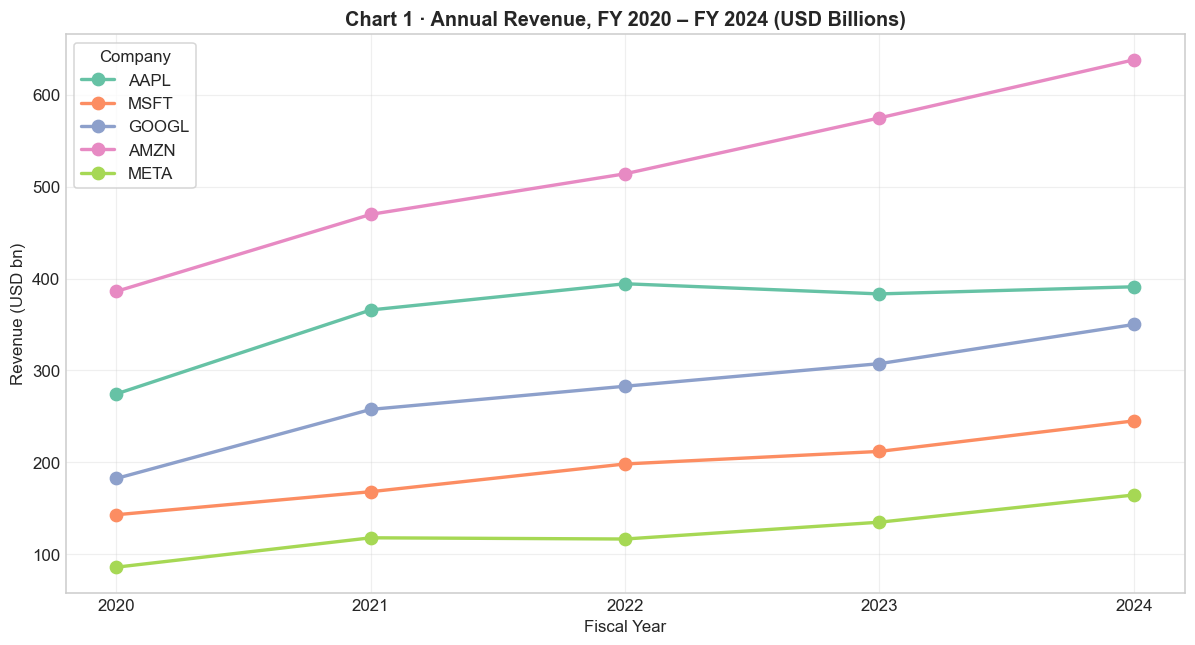

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))

for ticker in TICKERS:
    sub = df[df['tic'] == ticker].sort_values('fyear')
    ax.plot(sub['fyear'], sub['revenue_bn'],
            marker='o', linewidth=2.2, markersize=8, label=ticker)

ax.set_title('Chart 1 · Annual Revenue, FY 2020 – FY 2024 (USD Billions)')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Revenue (USD bn)')
ax.set_xticks(sorted(df['fyear'].unique()))
ax.legend(title='Company', loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/01_revenue_trend.png', bbox_inches='tight')
plt.show()

### Insights — Chart 1

- **Amazon and Apple are the two revenue giants.** Both cleared the \$380 bn mark by FY 2024, reflecting the scale of physical goods businesses (Amazon's marketplace and logistics; Apple's hardware). Revenue alone, however, says nothing about how much of each dollar the firm keeps — margins in Chart 3 will re-rank the group.
- **Microsoft, Alphabet and Meta sit in a lower band** (roughly \$130 bn – \$250 bn). Their growth slopes are visibly steeper than Apple's because they are software- and advertising-led and do not carry the same cost-of-goods drag.
- **2022 is the first visible inflection** — Meta's line flattens in FY 2022 as post-pandemic ad-budget cuts hit, and Amazon's slope also softens. The divergence between 2022 and 2023 tells the story of the AI-led re-acceleration in 2023–2024.
- **Apple is the only firm whose revenue line is almost flat between FY 2022 and FY 2024.** iPhone saturation and a maturing smartphone market show up very clearly in this picture — Apple's growth narrative has moved from hardware units to services and margin expansion, which will be visible in Chart 3.

A line chart of *dollar* revenue is the right first look, but the remaining six charts progressively strip out scale effects so we can compare structure, not size.

## 7. Chart 2 — Net Income Trend

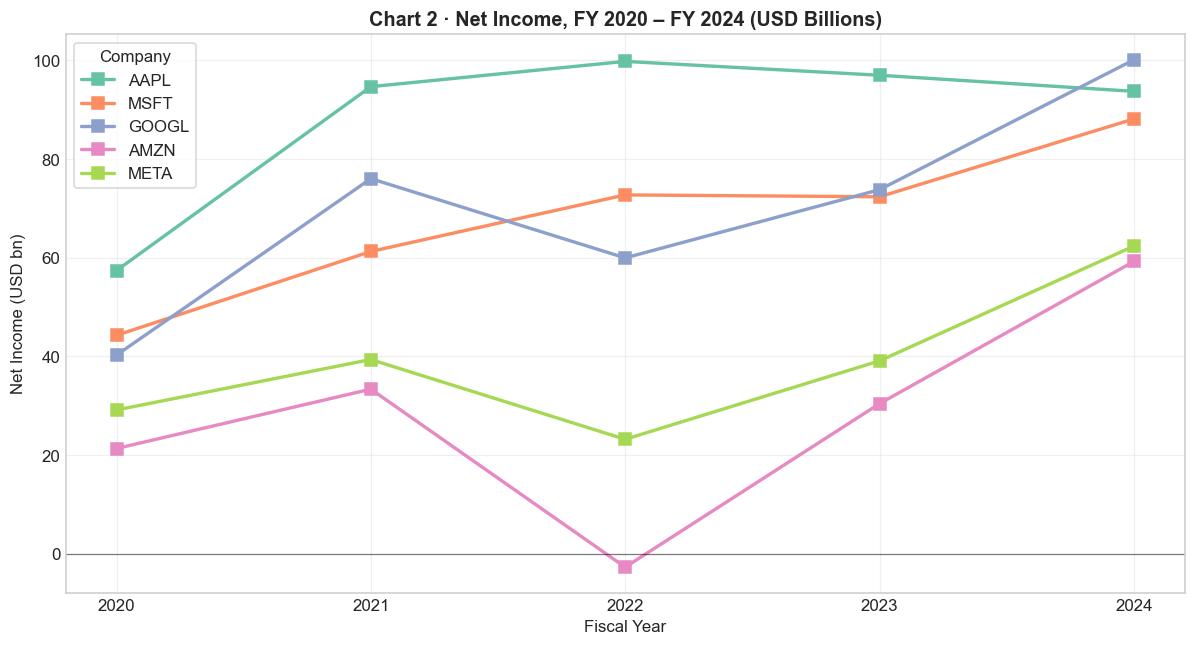

In [28]:
fig, ax = plt.subplots(figsize=(11, 6))

for ticker in TICKERS:
    sub = df[df['tic'] == ticker].sort_values('fyear')
    ax.plot(sub['fyear'], sub['net_income_bn'],
            marker='s', linewidth=2.2, markersize=8, label=ticker)

ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Chart 2 · Net Income, FY 2020 – FY 2024 (USD Billions)')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Net Income (USD bn)')
ax.set_xticks(sorted(df['fyear'].unique()))
ax.legend(title='Company', loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/02_net_income_trend.png', bbox_inches='tight')
plt.show()


### Insights — Chart 2

- **Ranking inverts from Chart 1.** Apple and Microsoft are the two most profitable firms by net income, not Amazon. Amazon's huge top line is dominated by thin-margin retail; Apple and Microsoft convert a much larger share of revenue into earnings.
- **The 2022 dip is synchronised across four firms.** Rising rates, strengthening USD, and a post-pandemic demand correction compressed earnings simultaneously — a textbook case of *macro co-movement* that will drive the positive correlations we see in Chart 7.
- **Meta's V-shape is the sharpest feature on the chart.** Net income fell roughly 40% in FY 2022 on the twin shocks of Apple's ATT privacy change (depressing ad targeting) and heavy capex on the Reality Labs segment, then recovered strongly in FY 2023–2024 as the ad business reaccelerated and cost discipline took hold.
- **Microsoft's line is the smoothest.** Enterprise software's recurring-revenue model produces visibly lower earnings volatility than either advertising (Meta, Alphabet) or hardware (Apple).

Net income alone still conflates size and profitability; a \$30 bn profit means very different things at \$200 bn of revenue versus \$600 bn. The next three charts normalise for scale.

## 8. Chart 3 — Gross Margin Comparison

Gross margin = (Revenue − Cost of Goods Sold) ÷ Revenue. It is a structural measure of the business model itself — it strips out overhead, R&D, tax, and one-offs, and shows how much of each sales dollar survives after the direct cost of delivering the product.

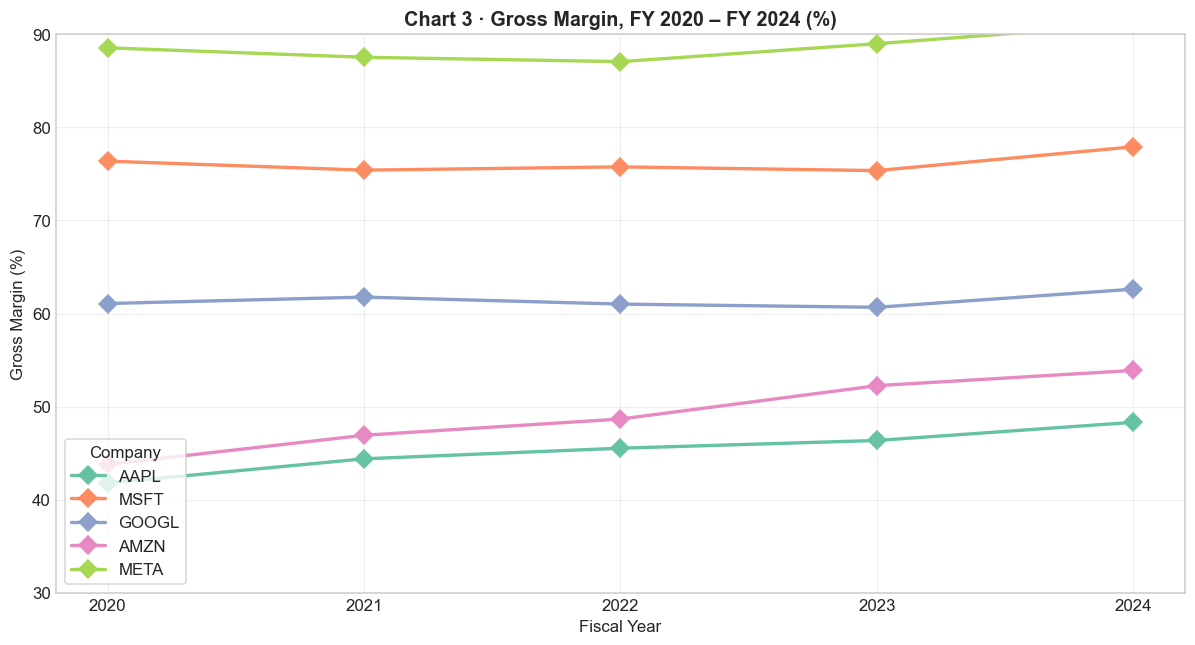

In [29]:
fig, ax = plt.subplots(figsize=(11, 6))

for ticker in TICKERS:
    sub = df[df['tic'] == ticker].sort_values('fyear')
    ax.plot(sub['fyear'], sub['gross_margin'] * 100,
            marker='D', linewidth=2.2, markersize=8, label=ticker)

ax.set_title('Chart 3 · Gross Margin, FY 2020 – FY 2024 (%)')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Gross Margin (%)')
ax.set_xticks(sorted(df['fyear'].unique()))
ax.set_ylim(30, 90)
ax.legend(title='Company', loc='lower left', frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/03_gross_margin.png', bbox_inches='tight')
plt.show()

### Insights — Chart 3

- **The group splits cleanly into three tiers.**
  - **Upper tier (~75–80%):** Meta and Microsoft. Software and digital ads have near-zero marginal cost — once the code is written and the user acquired, each additional dollar of revenue costs very little to deliver.
  - **Middle tier (~55%):** Alphabet. Similar economics to Meta, but weighed down by YouTube content costs and traffic-acquisition payments to Apple/Samsung.
  - **Lower tier (~40–45%):** Apple, then Amazon. Apple's hardware has real bill-of-materials cost; Amazon's retail segment is intrinsically low-margin and only recent AWS weighting lifts the blended figure.
- **Apple's gross margin is visibly drifting up** across the window. The well-documented mix shift from hardware to Services (App Store, iCloud, Apple Music) is doing exactly what Apple's management guides to — Services carry software-like margins and now represent a growing share of the revenue base.
- **Meta's margin recovered sharply from its FY 2022 trough.** The combination of cost cuts ("Year of Efficiency", 2023) and operating leverage on recovering ad revenue pushed gross margin back toward its pre-2022 level.
- **Amazon's margin is the most informative for business-model watchers.** A gradually rising gross margin on a retail base almost certainly reflects an increasing AWS and advertising mix within the consolidated total, not a change in retail economics.

This chart, more than any other in the deck, is why a peer comparison of *tech* companies is misleading if you only look at the top line.

## 9. Chart 4 — Revenue Growth Rate (Year-over-Year)

Because revenue growth for FY 2020 requires FY 2019 as a base, the first plotted year is FY 2021.

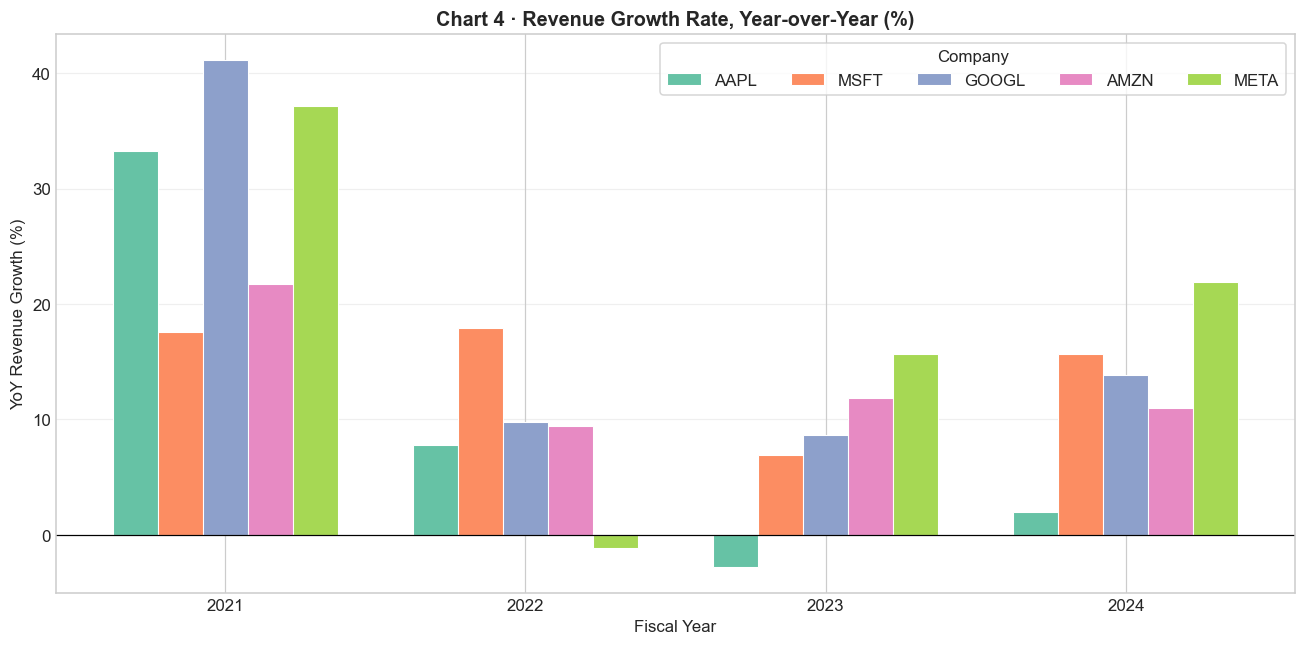

In [30]:
growth_df = df.dropna(subset=['revenue_growth']).copy()

fig, ax = plt.subplots(figsize=(12, 6))

x = sorted(growth_df['fyear'].unique())
width = 0.15
for i, ticker in enumerate(TICKERS):
    sub = growth_df[growth_df['tic'] == ticker].sort_values('fyear')
    offset = (i - 2) * width
    ax.bar(sub['fyear'] + offset, sub['revenue_growth'] * 100,
           width=width, label=ticker, edgecolor='white', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Chart 4 · Revenue Growth Rate, Year-over-Year (%)')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('YoY Revenue Growth (%)')
ax.set_xticks(x)
ax.legend(title='Company', loc='upper right', frameon=True, ncol=5)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/04_revenue_growth.png', bbox_inches='tight')
plt.show()

### Insights — Chart 4

- **2021 was the pandemic high-water mark.** Every firm except Apple posted double-digit growth — consumer electronics, online advertising, cloud workloads, and e-commerce all benefited from lockdown-era demand pull-forward. This is the bar to beat, and it warps any comparison that uses FY 2021 as a base year.
- **2022 is Meta's worst year and a warning shot for the group.** Meta actually contracted (negative bar), while Amazon and Alphabet decelerated sharply. The common drivers — rate hikes, strong-dollar FX translation, the ATT policy shock for ad-funded businesses — affected every firm, but hit ad-dependent models hardest.
- **The 2023–2024 rebound is cloud-and-AI led.** Microsoft's bars are the most consistent in the window — Azure and Copilot revenues provided a cushion that hardware-sensitive names (Apple) did not have. Microsoft's re-acceleration from FY 2023 to FY 2024 is the most important qualitative story in this chart.
- **Apple's growth profile has fundamentally changed.** Low-single-digit growth is the new normal for the iPhone business at today's scale. The investment thesis on Apple is no longer a revenue-growth thesis; it is a margin-expansion and capital-return thesis — which is why Chart 3 and Chart 5 matter more for Apple than this chart does.

Growth rates are the most useful *scale-free* metric for a junior analyst: they let you compare a \$200 bn firm with a \$600 bn firm on equal footing.

## 10. Chart 5 — Net Profit Margin

Net margin = Net Income ÷ Revenue. Unlike gross margin, this is an *all-in* profitability measure — it reflects operating efficiency, financing, tax, and one-off items. The gap between a firm's gross and net margins tells you how expensive the rest of the organisation (R&D, sales & marketing, G&A, interest, tax) is.

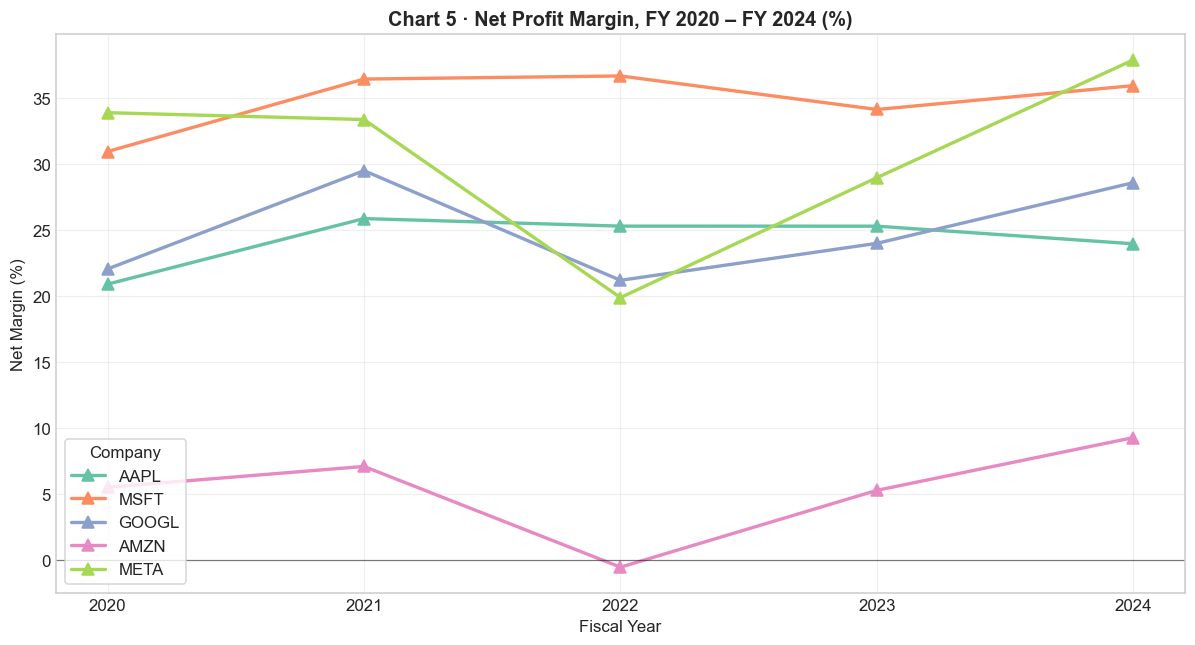

In [31]:
fig, ax = plt.subplots(figsize=(11, 6))

for ticker in TICKERS:
    sub = df[df['tic'] == ticker].sort_values('fyear')
    ax.plot(sub['fyear'], sub['net_margin'] * 100,
            marker='^', linewidth=2.2, markersize=8, label=ticker)

ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Chart 5 · Net Profit Margin, FY 2020 – FY 2024 (%)')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Net Margin (%)')
ax.set_xticks(sorted(df['fyear'].unique()))
ax.legend(title='Company', loc='lower left', frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/05_net_margin.png', bbox_inches='tight')
plt.show()

### Insights — Chart 5

- **Microsoft is the most profitable of the five on a net-margin basis**, typically above 30%. This is the payoff of a recurring-revenue, software-dominated mix with disciplined opex management.
- **Apple's net margin sits in the mid-20s.** Despite its relatively modest gross margin (Chart 3), Apple converts revenue to profit very efficiently because its R&D and S&M as a percentage of sales are lower than software-heavy peers — a direct consequence of scale.
- **Meta's V-shape repeats itself**, and more dramatically than in absolute net income. Net margin fell into the high teens in FY 2022 and recovered above 30% by FY 2024 — one of the fastest profitability recoveries in megacap tech.
- **Amazon's net margin is in a completely different universe** (frequently low-single-digit, and briefly *negative* in FY 2022 on a valuation write-down of the Rivian stake). This single chart is the clearest visual reason why Amazon is consistently valued on EV/sales or EV/EBITDA rather than P/E — conventional earnings multiples distort the picture for a mixed retail / cloud / advertising business.
- **Alphabet is the most stable of the high-margin names.** Core Search remains a mature cash engine; variability comes from Google Cloud's path to profitability and from one-off items (EU fines, regulatory settlements).

Net margin is the metric that most closely tracks how the market prices these firms day-to-day. The large 2022 drawdown in tech equities lines up closely with the 2022 trough in this chart.

## 11. Chart 6 — Scale Comparison (Most Recent Fiscal Year)

A grouped bar chart puts revenue, net income and total assets on the same panel for the latest available year. This is the chart most likely to end up in a CV or one-pager — it is immediately readable without any finance background.

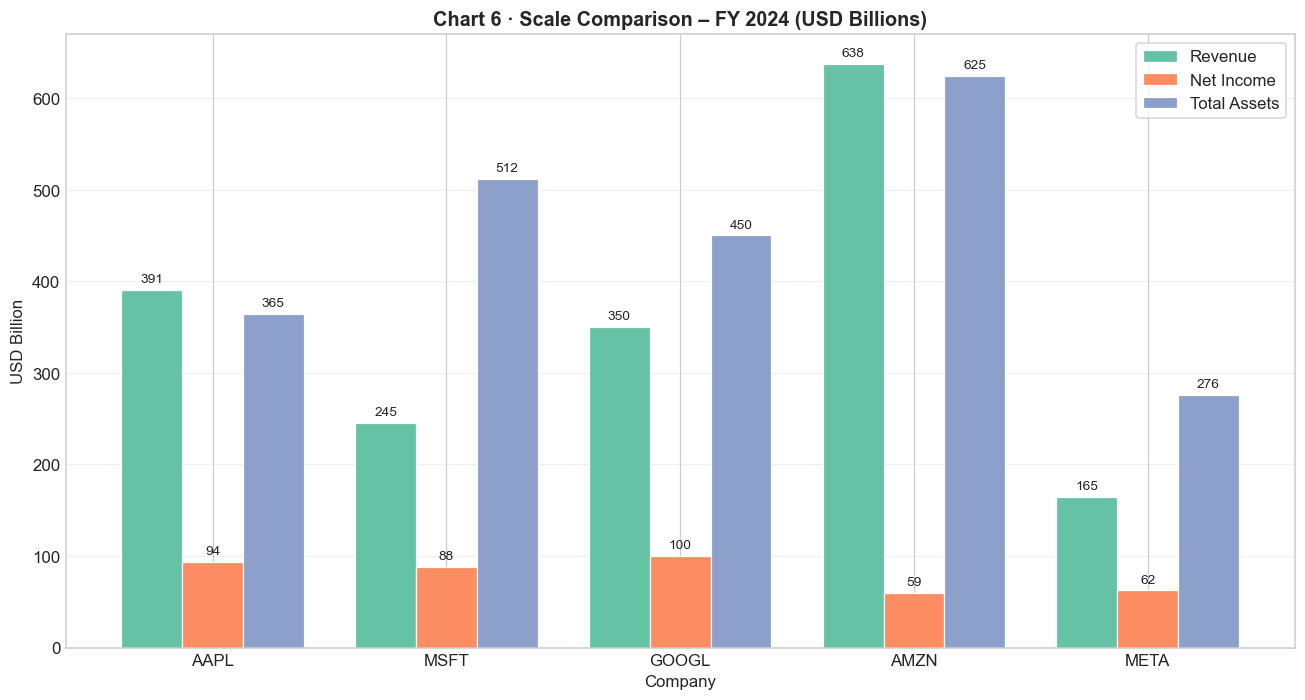

In [32]:
latest_year = int(df['fyear'].max())
latest = df[df['fyear'] == latest_year].set_index('tic').reindex(TICKERS)

fig, ax = plt.subplots(figsize=(12, 6.5))

x = np.arange(len(TICKERS))
width = 0.26

b1 = ax.bar(x - width, latest['revenue_bn'],      width, label='Revenue',       edgecolor='white', linewidth=0.8)
b2 = ax.bar(x,         latest['net_income_bn'],   width, label='Net Income',    edgecolor='white', linewidth=0.8)
b3 = ax.bar(x + width, latest['total_assets_bn'], width, label='Total Assets',  edgecolor='white', linewidth=0.8)

# Numeric labels on bars
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        if pd.notna(h):
            ax.annotate(f'{h:,.0f}',
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=9)

ax.set_title(f'Chart 6 · Scale Comparison – FY {latest_year} (USD Billions)')
ax.set_xlabel('Company')
ax.set_ylabel('USD Billion')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.legend(frameon=True)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/06_scale_bar.png', bbox_inches='tight')
plt.show()

### Insights — Chart 6

- **Three different scale axes tell three different stories.** Amazon dominates revenue; Apple dominates net income; Amazon again leads on total assets (warehouses, fulfilment, AWS data centres). No single firm leads on all three simultaneously.
- **The revenue-vs-net-income gap is the most striking contrast.** Amazon's revenue is roughly comparable to Apple's, but Amazon's net income is a fraction of Apple's — a visual confirmation of the margin gap uncovered in Charts 3 and 5.
- **Total assets vs revenue reveals capital intensity.** Amazon has the largest asset base relative to its peers — logistics real estate, aircraft, server fleets all sit on the balance sheet. Meta is the most asset-light relative to its revenue, consistent with an advertising business model that runs mostly on compute and software.
- **This chart is deliberately plain.** For a CV-facing one-pager, the point is to be readable in three seconds, not to reveal every nuance. The nuance lives in the other six charts.

Grouping three mixed-unit metrics on one axis is a defensible choice here because all three are in the same currency and in the same order of magnitude (tens to hundreds of billions). If total assets dwarfed the other two — as can happen for banks — a split-axis or log scale would be needed.

## 12. Chart 7 — Correlation Heatmap of Key Financial Metrics

This chart takes the pooled panel (5 firms × 5 years = 25 observations) and computes the Pearson correlation between the key financial variables. The heatmap shows which metrics move together and which diverge.

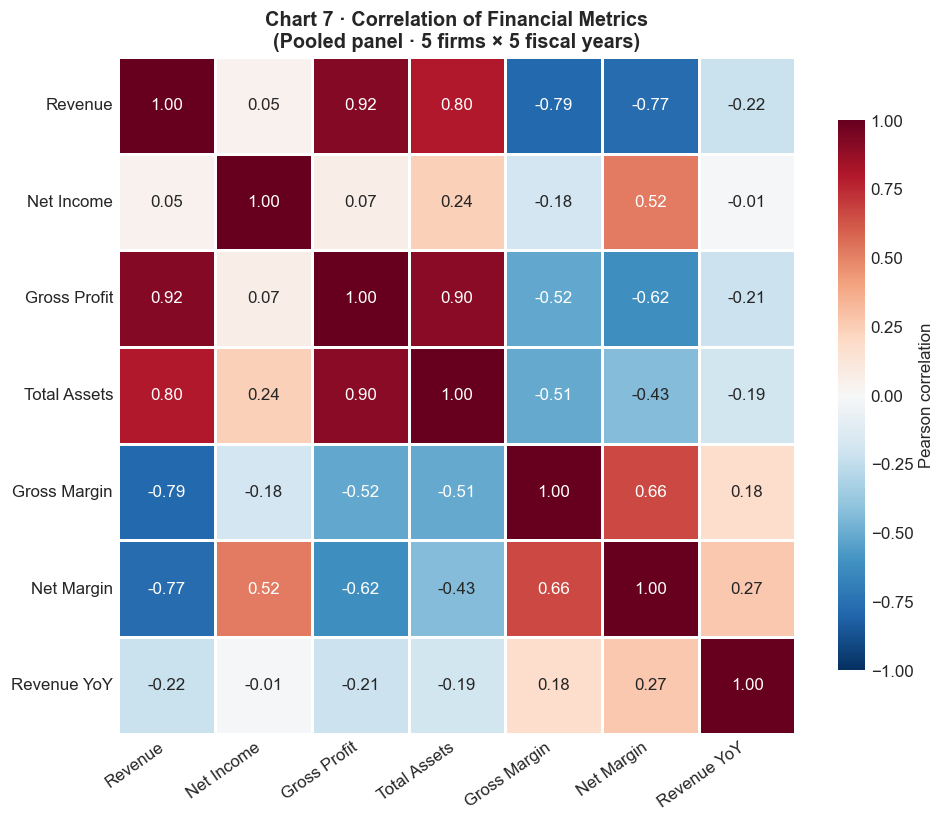

,Revenue,Net Income,Gross Profit,Total Assets,Gross Margin,Net Margin,Revenue YoY
Revenue,1.00,0.05,0.92,0.80,-0.79,-0.77,-0.22
Net Income,0.05,1.00,0.07,0.24,-0.18,0.52,-0.01
Gross Profit,0.92,0.07,1.00,0.90,-0.52,-0.62,-0.21
Total Assets,0.80,0.24,0.90,1.00,-0.51,-0.43,-0.19
Gross Margin,-0.79,-0.18,-0.52,-0.51,1.00,0.66,0.18
Net Margin,-0.77,0.52,-0.62,-0.43,0.66,1.00,0.27
Revenue YoY,-0.22,-0.01,-0.21,-0.19,0.18,0.27,1.00


In [33]:
corr_cols = [
    'revenue_bn', 'net_income_bn', 'gross_profit_bn',
    'total_assets_bn', 'gross_margin', 'net_margin', 'revenue_growth'
]
pretty = {
    'revenue_bn':      'Revenue',
    'net_income_bn':   'Net Income',
    'gross_profit_bn': 'Gross Profit',
    'total_assets_bn': 'Total Assets',
    'gross_margin':    'Gross Margin',
    'net_margin':      'Net Margin',
    'revenue_growth':  'Revenue YoY',
}

corr = df[corr_cols].corr().rename(index=pretty, columns=pretty)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.8,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson correlation'},
    ax=ax,
)
ax.set_title('Chart 7 · Correlation of Financial Metrics\n(Pooled panel · 5 firms × 5 fiscal years)')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('figures/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

corr.round(2)

### Insights — Chart 7

- **Revenue, net income, gross profit and total assets all correlate strongly with each other (typically > 0.8).** This is almost mechanical — bigger firms tend to be bigger on every absolute dimension. The useful information is not in these cells; it is in the margin columns.
- **Gross margin and net margin correlate strongly with each other but only weakly with revenue.** This is the single most important finding on the heatmap: **size does not buy profitability in this peer group**. Amazon is huge but not margin-rich; Microsoft is merely large and highly margin-rich. Any thesis that "scale → margin" is not supported by the pooled 2020–2024 data for these five firms.
- **Revenue growth has a near-zero correlation with raw revenue.** Another way of saying the law of large numbers is kicking in for the biggest names. The largest firm by dollars is not necessarily the fastest-growing firm by percent.
- **Net margin correlates moderately positively with gross margin (≈ 0.6–0.7).** Firms that deliver cheaply at the gross line tend to preserve that advantage all the way down to net income — but the correlation is noticeably below 1, meaning operating discipline (opex, R&D intensity, capital structure) matters for the final-line profitability story.
- **A caveat on sample size.** With only 25 pooled observations, the numbers in individual cells should be read as directional rather than statistically precise. In the reflection I discuss this and how to extend to a larger industry-wide panel.

**Note on interpretation.** Correlation here mixes *cross-sectional* variation (Amazon vs Microsoft) and *time-series* variation (2020 vs 2024) in one coefficient. A rigorous extension would separate the two by demeaning within firm — flagged in the limitations.

## 13. Cross-Company Synthesis

Bringing the seven charts together, the Big Five are better understood as **three distinct business models** than as a single "Big Tech" cohort:

| Archetype | Members | Signature in the charts |
|---|---|---|
| **Asset-heavy, scale-driven, low margin** | Amazon | Leader in revenue and total assets; modest net income; low and volatile net margin |
| **Premium hardware / platform hybrid** | Apple | Large revenue and huge net income; mid-tier gross margin but rising on services mix |
| **Asset-light, software / ads, high margin** | Microsoft, Alphabet, Meta | Smaller revenue than Apple/Amazon, but gross margins 55–80% and net margins 20–35% |

The **2022 trough → 2024 recovery** appears in every one of the five non-Amazon firms, but the depth and speed of recovery differ markedly — Meta's V is the sharpest, Microsoft's line is the smoothest, and Apple's growth rebound is the weakest. The same macro shock did not affect these companies symmetrically, and that asymmetry is the useful signal for an analyst.

For the target user — a junior analyst or finance student — the practical takeaway is: **do not benchmark a tech name against "Big Tech"; benchmark it against its archetype peers.** Comparing Apple's revenue growth to Microsoft's is interesting; comparing Amazon's net margin to Apple's is not.


## 14. Reusable Functions

Following the Week 6 lecture, the workflow is wrapped into functions so the same pipeline can be re-run next quarter with no notebook edits, and so the functions can be imported by an Agent / plugin (e.g. Coze, Dify).

In [34]:
def fetch_tech_fundamentals(db, tickers, start_date, end_date):
    """
    Pull Compustat annual fundamentals for a list of tickers between two dates.

    Parameters
    ----------
    db : wrds.Connection
        An open WRDS connection.
    tickers : list[str]
        Compustat tickers, e.g. ['AAPL', 'MSFT'].
    start_date, end_date : str
        ISO dates 'YYYY-MM-DD'.

    Returns
    -------
    pandas.DataFrame
        Raw firm-year rows with the full Compustat screen applied.
    """
    tickers_sql = "', '".join(tickers)
    query = f"""
    SELECT a.tic, b.conm, a.gvkey, a.datadate, a.fyear,
           a.revt, a.cogs, a.gp, a.ni, a.oiadp, a.at
    FROM   comp.funda AS a
    LEFT JOIN comp.company AS b ON a.gvkey = b.gvkey
    WHERE  a.tic IN ('{tickers_sql}')
      AND  a.datadate BETWEEN '{start_date}' AND '{end_date}'
      AND  a.indfmt  = 'INDL'
      AND  a.datafmt = 'STD'
      AND  a.popsrc  = 'D'
      AND  a.consol  = 'C'
    ORDER BY a.tic, a.fyear
    """
    return db.raw_sql(query)


def build_financial_panel(raw_df):
    """Clean the raw Compustat pull and add derived ratios."""
    d = raw_df.dropna(subset=['fyear', 'revt']).copy()
    d['fyear']        = d['fyear'].astype(int)
    d['gross_profit'] = d['revt'] - d['cogs']
    for c, nc in [('revt','revenue_bn'), ('ni','net_income_bn'),
                  ('gross_profit','gross_profit_bn'),
                  ('at','total_assets_bn'), ('oiadp','op_income_bn')]:
        d[nc] = d[c] / 1_000
    d['gross_margin'] = d['gross_profit'] / d['revt']
    d['net_margin']   = d['ni']           / d['revt']
    d = d.sort_values(['tic','fyear']).reset_index(drop=True)
    d['revenue_growth'] = d.groupby('tic')['revt'].pct_change()
    return d


def summary_markdown(panel):
    """Render the panel as a markdown table — convenient for feeding into an LLM prompt."""
    cols = ['tic','fyear','revenue_bn','net_income_bn',
            'gross_margin','net_margin','revenue_growth']
    return panel[cols].round(3).to_markdown(index=False)


# Quick demo of the pipeline — identical to what the notebook did above
demo = build_financial_panel(fetch_tech_fundamentals(
    db, TICKERS, START_DATE, END_DATE
))
print(f'Function pipeline produced {len(demo)} rows.')
demo.head()

Function pipeline produced 25 rows.


,tic,conm,gvkey,datadate,fyear,revt,cogs,gp,ni,oiadp,at,gross_profit,revenue_bn,net_income_bn,gross_profit_bn,total_assets_bn,op_income_bn,gross_margin,net_margin,revenue_growth
0,AAPL,APPLE INC,001690,2020-09-30,2020,274515.0,159859.0,114656.0,57411.0,66288.0,323888.0,114656.0,274.515,57.411,114.656,323.888,66.288,0.417668,0.209136,<NA>
1,AAPL,APPLE INC,001690,2021-09-30,2021,365817.0,203481.0,162336.0,94680.0,108949.0,351002.0,162336.0,365.817,94.68,162.336,351.002,108.949,0.443763,0.258818,0.332594
2,AAPL,APPLE INC,001690,2022-09-30,2022,394328.0,214846.0,179482.0,99803.0,119437.0,352755.0,179482.0,394.328,99.803,179.482,352.755,119.437,0.455159,0.253096,0.077938
3,AAPL,APPLE INC,001690,2023-09-30,2023,383285.0,205637.0,177648.0,96995.0,114301.0,352583.0,177648.0,383.285,96.995,177.648,352.583,114.301,0.463488,0.253062,-0.028005
4,AAPL,APPLE INC,001690,2024-09-30,2024,391035.0,202152.0,188883.0,93736.0,123216.0,364980.0,188883.0,391.035,93.736,188.883,364.98,123.216,0.483033,0.239713,0.02022


These three functions turn the whole notebook into a 3-line pipeline, which is exactly what an Agent plugin needs. Concretely:

```python
raw   = fetch_tech_fundamentals(db, TICKERS, START_DATE, END_DATE)
panel = build_financial_panel(raw)
md    = summary_markdown(panel)   # feed directly into an AI prompt
```


## 15. Limitations & Next Steps

**Data scope.** 25 observations is small; statistical claims (especially the correlation coefficients) are directional rather than precise. An obvious extension is the full S&P 500 Information Technology sector, which would put the Big Five in proper peer context.

**Segment data is not used.** Apple's Services segment and Amazon's AWS are the most important growth stories inside their parent companies, but they are invisible at the consolidated-statement level used here. A richer version of this project would pull Compustat's `comp.segments` tables and build segment-level revenue and operating-income trajectories.

**Net income is a noisy profitability measure.** One-off items (Amazon's Rivian write-down in FY 2022, Alphabet's EU fines, Meta's Reality Labs losses) can dominate a single year. A cleaner version would use operating income (`oiadp`) or EBITDA as the profitability anchor.

**Correlation conflates cross-section and time-series.** A proper decomposition would demean each variable within firm (remove firm fixed effects) before computing the correlation matrix, so the numbers reflect co-movement over time rather than cross-firm ranking.

**SQL injection.** The f-string pattern is fine for a teaching notebook with controlled inputs, but for a production service the parameters should be bound via `%s` placeholders, not string-interpolated.

**Currency and restatements.** Compustat's USD-denominated standardised data is appropriate for US firms, but I have not checked for restated figures; if any of the five firms issued a material restatement within the window, the affected row would need to be refreshed.

**Next steps.** (1) Extend to the full S&P 500 IT sector. (2) Add segment-level revenue with `comp.segments`. (3) Layer in market-cap and valuation multiples from CRSP to tie the fundamentals story to equity performance. (4) Wrap the three functions into a Coze plugin (Track 3) for interactive exploration.


---

### Close WRDS connection

In [35]:
db.close()
print('WRDS connection closed.')

WRDS connection closed.
